In [1]:
import pandas as pd

In [2]:
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier

In [4]:
dig = load_digits()
df = pd.DataFrame(dig.data,dig.target)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [5]:
df['target']=dig.target
print(df['target'])

0    0
1    1
2    2
3    3
4    4
    ..
9    9
0    0
8    8
9    9
8    8
Name: target, Length: 1797, dtype: int32


In [6]:
df['target'].value_counts()

target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64

In [8]:
X=df.drop(columns='target',axis=1)
Y=df['target']
X_train,X_test,Y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=10)
knn=KNeighborsClassifier(n_neighbors=3)


In [11]:
knn.fit(X_train,Y_train)
print("Model Accuracy:",knn.score(X_test,y_test))

Model Accuracy: 0.9907407407407407


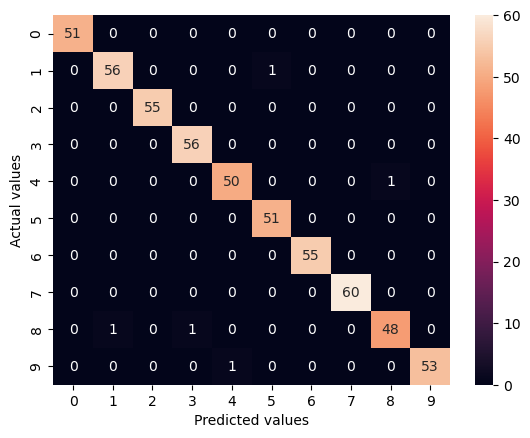

In [12]:
pred_y = knn.predict(X_test)
cm=confusion_matrix(y_test,pred_y)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

In [15]:
k_range = range(3,40)
er = []
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i,metric='euclidean')
    knn.fit(X_train,Y_train)
    pred_i = knn.predict(X_test)
    er.append(np.mean(pred_i != y_test))

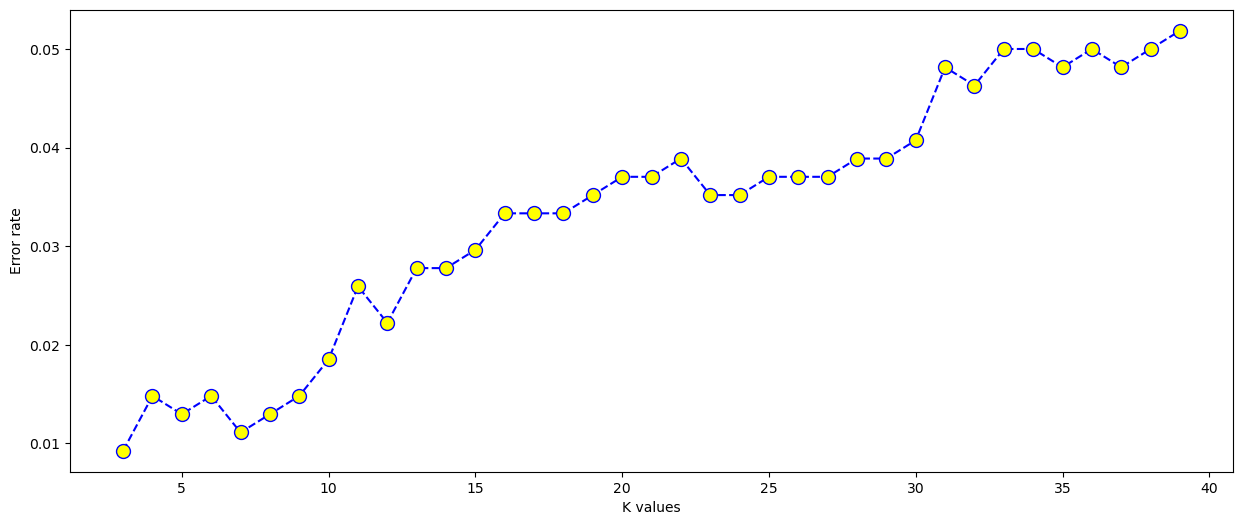

In [17]:
plt.figure(figsize=(15,6))
plt.plot(k_range,er,color='blue',linestyle='dashed',marker='o',markerfacecolor='yellow',markersize=10)
plt.xlabel("K values")
plt.ylabel("Error rate")
plt.show()

In [18]:
opt_k = k_range[np.argmin(er)]
print(opt_k)

3
